# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuicao Fisica**

---

## **Aula 2 -- Preparacao, tratamento e estruturacao da base de dados**

**Grupo 2:** Rodrigo Pimentel, Bernardo Caula, Joao Felipe Leal, Lucas Campos, Lucas Terzi

---

## Objetivos

1. Transformar a base operacional real em estrutura de dados adequada para modelagem do CVRP;
2. Construir as entradas do modelo: conjunto de nos, vetor de demanda, matrizes de distancias, custos e tempos;
3. Gerar instancias C1-C4 com tamanhos crescentes para analise de escalabilidade;
4. Exportar datasets para a Aula 3 (solucao exata via PLI).

## Configuracao logistica do problema (parametros)

In [1]:
import pandas as pd
import numpy as np
import math
import itertools
import random
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Deposito (origem e destino de todas as rotas)
DEPOT_CEP = "25251560"

# Veiculos
VEHICLES = {
    "Fiorino": {"Q_kg": 650,  "custo_fixo_diario": 250},
    "VUC":     {"Q_kg": 3000, "custo_fixo_diario": 550},
}

# Custos e tempos
g = 1.50                  # custo variavel (R$/km)
v_kmh = 40.0              # velocidade media (km/h)
s_min = 15.0              # tempo de atendimento (min)
H_horas = 8.0             # jornada maxima (h)

# Conversoes
s_horas = s_min / 60.0    # s em horas
H_min = H_horas * 60.0    # jornada em minutos

# Equipe
EQUIPE_ID = 2

## 1. Leitura da base operacional

In [2]:
file_name = "../../Base de Dados.xlsx"

df_raw = pd.read_excel(file_name)

display(df_raw.head())
print(f"Dimensoes da base bruta: {df_raw.shape}")
df_raw.info()

,DataEmissao,CEP Entrega,Qtd volumes,Peso real (kg),Valor da mercadoria (R$)
0,2025-06-03,26383060,5,20.424,724.23
1,2025-06-03,26383080,3,9.336,797.38
2,2025-06-03,26383060,1,1.180,24.46
3,2025-06-03,26325282,1,3.174,595.71
4,2025-06-03,26311110,14,120.802,3600.79


Dimensoes da base bruta: (1021, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DataEmissao               1021 non-null   datetime64[ns]
 1   CEP Entrega               1021 non-null   int64         
 2   Qtd volumes               1021 non-null   int64         
 3   Peso real (kg)            1021 non-null   float64       
 4   Valor da mercadoria (R$)  1021 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 40.0 KB


## 2. Padronizacao e agregacao por cliente (CEP)

No CVRP, cada cliente $i$ deve ser um no unico. Se o mesmo CEP aparece varias vezes, somamos as demandas:

$$q_i = \sum_{\ell \in \text{linhas do CEP}} q_\ell$$

In [3]:
df = df_raw.copy()

# Identifica coluna do CEP
col_cep = None
for c in df.columns:
    c_low = str(c).lower()
    if "rotulos" in c_low or "rotulos" in c_low or c_low.strip() == "cep" or "cep" in c_low:
        col_cep = c
        break
if col_cep is None:
    raise ValueError("Nao encontrei a coluna de CEP. Verifique o Excel.")

df = df.rename(columns={col_cep: "CEP"})

def find_col_by_keywords(columns, keywords):
    for c in columns:
        name = str(c).lower()
        if all(k in name for k in keywords):
            return c
    return None

col_vol = find_col_by_keywords(df.columns, ["volume"]) or find_col_by_keywords(df.columns, ["volum"])
col_peso = find_col_by_keywords(df.columns, ["peso"]) or find_col_by_keywords(df.columns, ["kg"])
col_val  = find_col_by_keywords(df.columns, ["valor"]) or find_col_by_keywords(df.columns, ["mercadoria"])

missing = []
if col_vol is None: missing.append("VOLUMES")
if col_peso is None: missing.append("PESO")
if col_val is None: missing.append("VALOR")

if missing:
    print("Colunas disponiveis no Excel:")
    for c in df.columns:
        print("-", c)
    raise ValueError(f"Nao identifiquei as colunas: {missing}. Ajuste palavras-chave ou nomes no Excel.")

df = df.rename(columns={col_vol: "volumes", col_peso: "peso_kg", col_val: "valor_rs"})

# Padroniza CEP e filtra validos
df["CEP"] = df["CEP"].astype(str).str.replace(r"\D", "", regex=True)
df = df[df["CEP"].str.len() == 8].copy()

# Numericos
for col in ["volumes", "peso_kg", "valor_rs"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove invalidos
df = df.dropna(subset=["CEP", "volumes", "peso_kg", "valor_rs"])
df = df[(df["volumes"] >= 0) & (df["peso_kg"] >= 0) & (df["valor_rs"] >= 0)].copy()

# CEPs repetidos
rep = df["CEP"].value_counts()
rep = rep[rep > 1]
print(f"CEPs repetidos (mesmo cliente em multiplas linhas): {len(rep)}")
if len(rep) > 0:
    display(rep.head(10))

# Agrega por cliente (um no por CEP)
df = df.groupby("CEP", as_index=False).agg({
    "volumes": "sum",
    "peso_kg": "sum",
    "valor_rs": "sum",
})

print("Base consolidada (um cliente por CEP):", df.shape)
df.head()

CEPs repetidos (mesmo cliente em multiplas linhas): 243


CEP
22631002    10
22451540     9
22230060     6
22753212     6
22041012     6
25915000     6
25576011     6
22451350     6
23890001     6
26155070     6
Name: count, dtype: int64

Base consolidada (um cliente por CEP): (581, 4)


,CEP,volumes,peso_kg,valor_rs
0,20000001,24,120.003,5114.61
1,20080003,4,3.707,746.42
2,20080004,1,1.026,188.91
3,20211260,1,4.560,158.05
4,20211270,10,40.233,2278.68


## 3. Coordenadas e distancias

### 3.1 Distancia geografica (Haversine)

$$D_{ij} = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\phi_i-\phi_j}{2}\right) + \cos(\phi_i)\cos(\phi_j)\sin^2\left(\frac{\lambda_i-\lambda_j}{2}\right)}\right)$$

In [4]:
# Bounding box RJ (aproximacao)
LAT_MIN, LAT_MAX = -23.2, -22.3
LON_MIN, LON_MAX = -44.5, -42.8

def cep_to_latlon(cep: str):
    cep_num = int(cep)
    u = (cep_num % 10000) / 10000.0
    v = ((cep_num // 10000) % 10000) / 10000.0
    lat = LAT_MIN + u * (LAT_MAX - LAT_MIN)
    lon = LON_MIN + v * (LON_MAX - LON_MIN)
    return lat, lon

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

# Coordenadas dos clientes
df["lat"], df["lon"] = zip(*df["CEP"].apply(cep_to_latlon))

# Coordenadas do deposito
depot_lat, depot_lon = cep_to_latlon(DEPOT_CEP)
df.head()

,CEP,volumes,peso_kg,valor_rs,lat,lon
0,20000001,24,120.003,5114.61,-23.19991,-44.16000
1,20080003,4,3.707,746.42,-23.19973,-44.15864
2,20080004,1,1.026,188.91,-23.19964,-44.15864
3,20211260,1,4.560,158.05,-23.08660,-44.15643
4,20211270,10,40.233,2278.68,-23.08570,-44.15643


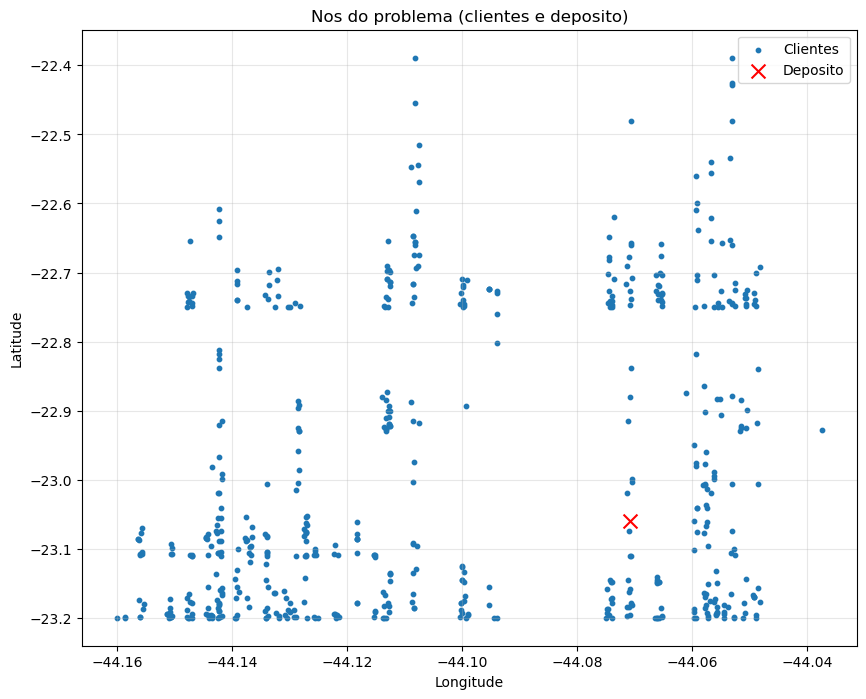

In [5]:
plt.figure(figsize=(10, 8))
plt.scatter(df["lon"], df["lat"], s=10, label="Clientes")
plt.scatter([depot_lon], [depot_lat], marker="x", s=100, c="red", label="Deposito")
plt.title("Nos do problema (clientes e deposito)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Construcao das matrizes logisticas $D_{ij}$, $c_{ij}$ e $t_{ij}$

- $D_{ij}$: distancia (km)
- $c_{ij} = g \cdot D_{ij}$: custo variavel (R$)
- $t_{ij} = D_{ij} / v$: tempo de deslocamento (h)

In [6]:
coords = [(depot_lat, depot_lon)] + list(zip(df["lat"], df["lon"]))
n_nodes = len(coords)

# D_ij
D = np.zeros((n_nodes, n_nodes), dtype=float)
for i, j in itertools.product(range(n_nodes), range(n_nodes)):
    if i != j:
        D[i, j] = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])

# Matriz de custo
Cvar = g * D

# Matriz de tempo
Tmov_h = D / v_kmh

print("Dimensoes:", D.shape, Cvar.shape, Tmov_h.shape)
print("Exemplo D (km) [0:5,0:5]:")
print(np.round(D[:5,:5], 2))

Dimensoes: (582, 582) (582, 582) (582, 582)
Exemplo D (km) [0:5,0:5]:
[[0.000e+00 1.808e+01 1.799e+01 1.798e+01 9.260e+00]
 [1.808e+01 0.000e+00 1.400e-01 1.400e-01 1.260e+01]
 [1.799e+01 1.400e-01 0.000e+00 1.000e-02 1.258e+01]
 [1.798e+01 1.400e-01 1.000e-02 0.000e+00 1.257e+01]
 [9.260e+00 1.260e+01 1.258e+01 1.257e+01 0.000e+00]]


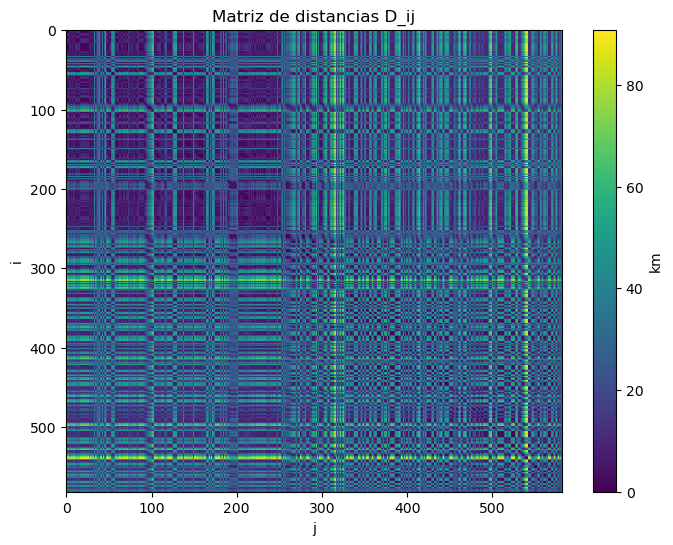

Distancia maxima (km): 90.84171761612939


In [7]:
plt.figure(figsize=(8, 6))
plt.imshow(D, aspect="auto")
plt.title("Matriz de distancias D_ij")
plt.xlabel("j")
plt.ylabel("i")
plt.colorbar(label="km")
plt.show()

print("Distancia maxima (km):", D.max())

## 5. Vetor de demanda $q_i$ e tempos de atendimento

In [8]:
# q_i: deposito tem demanda 0, clientes tem demanda = peso_kg
q = np.concatenate(([0.0], df["peso_kg"].to_numpy(dtype=float)))

# s_i: deposito tem atendimento 0, clientes tem s_horas
s = np.concatenate(([0.0], np.full(len(df), s_horas, dtype=float)))

print("Demanda total (kg) no dia:", q.sum())
print("Tempo de atendimento total (h) se visitar todos:", s.sum())

Demanda total (kg) no dia: 25324.009
Tempo de atendimento total (h) se visitar todos: 145.25


In [9]:
# Validacao: clientes inviaveis (demanda > capacidade maxima)
Q_max = max(v["Q_kg"] for v in VEHICLES.values())

clientes_inviaveis = np.where(q > Q_max)[0]
clientes_inviaveis = [i for i in clientes_inviaveis if i != 0]

if clientes_inviaveis:
    print("Clientes inviaveis detectados:")
    for idx in clientes_inviaveis:
        cep = df.iloc[idx - 1]["CEP"]
        peso = q[idx]
        excesso = peso - Q_max
        print(f"  Cliente {idx} | CEP: {cep} | Demanda: {peso:.2f} kg | Excesso: {excesso:.2f} kg")
    raise ValueError("Instancia inviavel: existe cliente com demanda > capacidade maxima.")
else:
    print("Nenhum cliente excede a capacidade maxima da frota.")

Nenhum cliente excede a capacidade maxima da frota.


## 6. Instancias C1-C4 (amostragem aleatoria reprodutivel)

- C1: 10 clientes
- C2: 25 clientes
- C3: 40 clientes
- C4: 60 clientes

Selecao com seed fixa para reprodutibilidade. Equipe 2 usa o segundo bloco de 60 clientes.

In [10]:
random.seed(42)

all_clients = list(range(1, n_nodes))
random.shuffle(all_clients)

n_equipes = 4
max_instancia = 60
clientes_necessarios = n_equipes * max_instancia

if len(all_clients) < clientes_necessarios:
    raise ValueError(
        f"Clientes insuficientes. Necessarios: {clientes_necessarios}, disponiveis: {len(all_clients)}"
    )

if not (1 <= EQUIPE_ID <= n_equipes):
    raise ValueError("EQUIPE_ID deve estar entre 1 e 4.")

inicio = (EQUIPE_ID - 1) * max_instancia
fim = inicio + max_instancia
clientes_base = all_clients[inicio:fim]

instancias = {
    "C1_10": [0] + clientes_base[:10],
    "C2_25": [0] + clientes_base[:25],
    "C3_40": [0] + clientes_base[:40],
    "C4_60": [0] + clientes_base[:60],
}

print(f"Instancias geradas para Equipe {EQUIPE_ID}")
for nome, nodes in instancias.items():
    print(f"  {nome}: {len(nodes)-1} clientes")

Instancias geradas para Equipe 2
  C1_10: 10 clientes
  C2_25: 25 clientes
  C3_40: 40 clientes
  C4_60: 60 clientes


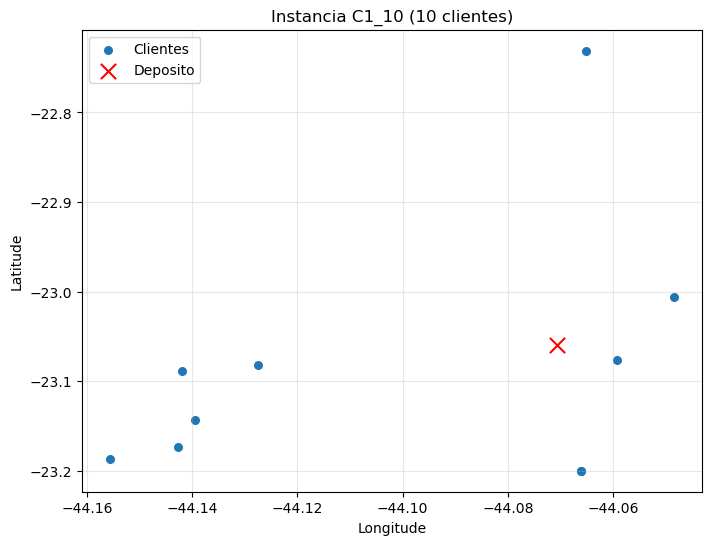

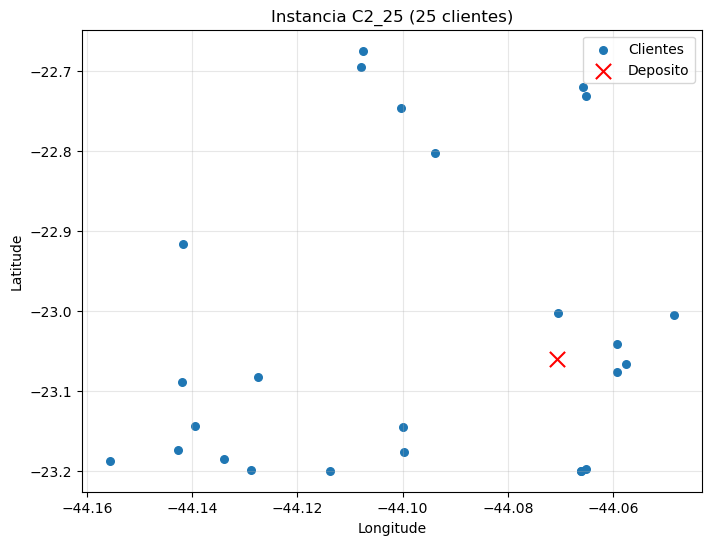

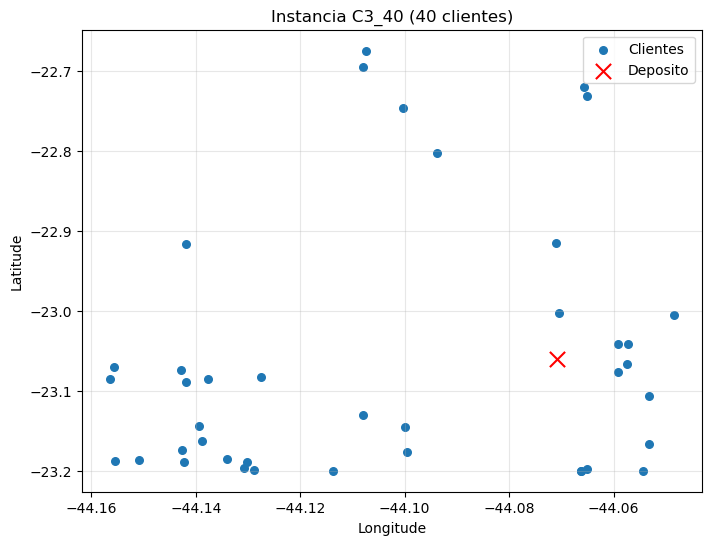

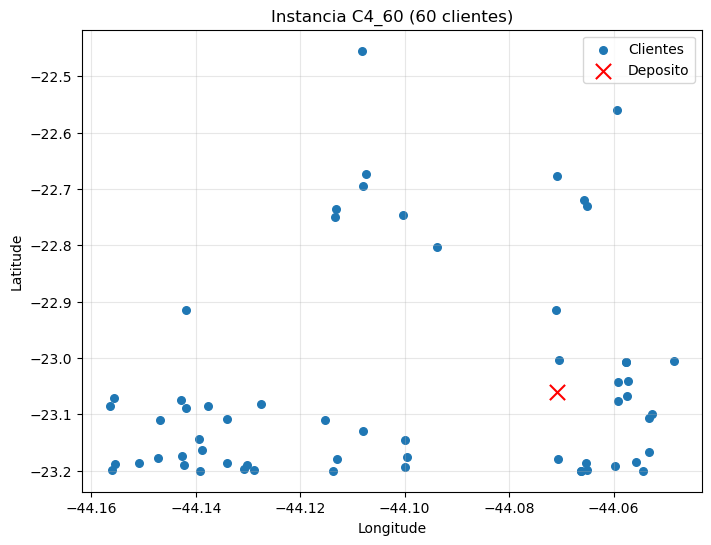

In [11]:
def plot_instancia(nome, nodes_list):
    clientes = [i for i in nodes_list if i != 0]

    lats_cli = [coords[i][0] for i in clientes]
    lons_cli = [coords[i][1] for i in clientes]

    plt.figure(figsize=(8, 6))
    plt.scatter(lons_cli, lats_cli, s=30, label="Clientes")
    plt.scatter([depot_lon], [depot_lat], marker="x", s=120, c="red", label="Deposito")
    plt.title(f"Instancia {nome} ({len(clientes)} clientes)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for nome, nodes_list in instancias.items():
    plot_instancia(nome, nodes_list)

## 7. Checagens de viabilidade (capacidade e jornada)

In [12]:
def resumo_instancia(nome, nodes_list):
    clientes = [i for i in nodes_list if i != 0]
    demanda_total = q[clientes].sum()

    n_fiorino = math.ceil(demanda_total / VEHICLES["Fiorino"]["Q_kg"])
    n_vuc = math.ceil(demanda_total / VEHICLES["VUC"]["Q_kg"])

    print(f"\nInstancia {nome} -- {len(clientes)} clientes")
    print(f"  Demanda total (kg): {demanda_total:.1f}")
    print(f"  Minimo teorico de Fiorinos (capacidade): {n_fiorino}")
    print(f"  Minimo teorico de VUCs (capacidade): {n_vuc}")

for nome, nodes_list in instancias.items():
    resumo_instancia(nome, nodes_list)


Instancia C1_10 -- 10 clientes
  Demanda total (kg): 141.6
  Minimo teorico de Fiorinos (capacidade): 1
  Minimo teorico de VUCs (capacidade): 1

Instancia C2_25 -- 25 clientes
  Demanda total (kg): 754.5
  Minimo teorico de Fiorinos (capacidade): 2
  Minimo teorico de VUCs (capacidade): 1

Instancia C3_40 -- 40 clientes
  Demanda total (kg): 1295.3
  Minimo teorico de Fiorinos (capacidade): 2
  Minimo teorico de VUCs (capacidade): 1

Instancia C4_60 -- 60 clientes
  Demanda total (kg): 1958.1
  Minimo teorico de Fiorinos (capacidade): 4
  Minimo teorico de VUCs (capacidade): 1


## 8. Exportacao dos datasets por instancia

Para cada instancia: `nodes.csv`, `D.npy`, `Cvar.npy`, `Tmov_h.npy`, `q.npy`, `s.npy`, `params.json`

In [13]:
out_dir = Path("datasets")
out_dir.mkdir(exist_ok=True)

def export_instancia(nome, nodes_global):
    local_map = {g_idx: idx for idx, g_idx in enumerate(nodes_global)}
    m = len(nodes_global)

    # Tabela de nos
    nodes_rows = []
    nodes_rows.append({
        "id": 0,
        "tipo": "depot",
        "CEP": DEPOT_CEP,
        "lat": depot_lat,
        "lon": depot_lon,
        "demanda_kg": 0.0,
        "volumes": 0.0,
        "valor_rs": 0.0
    })

    for g_idx in nodes_global:
        if g_idx == 0:
            continue
        row = df.iloc[g_idx - 1]
        nodes_rows.append({
            "id": local_map[g_idx],
            "tipo": "cliente",
            "CEP": row["CEP"],
            "lat": float(row["lat"]),
            "lon": float(row["lon"]),
            "demanda_kg": float(q[g_idx]),
            "volumes": float(row["volumes"]),
            "valor_rs": float(row["valor_rs"])
        })

    nodes_df = pd.DataFrame(nodes_rows).sort_values("id").reset_index(drop=True)

    # Submatrizes e vetores locais
    idx = np.array(nodes_global, dtype=int)
    D_loc = D[np.ix_(idx, idx)]
    C_loc = Cvar[np.ix_(idx, idx)]
    T_loc = Tmov_h[np.ix_(idx, idx)]
    q_loc = q[idx]
    s_loc = s[idx]

    # Salvar
    inst_dir = out_dir / nome
    inst_dir.mkdir(exist_ok=True)

    nodes_df.to_csv(inst_dir / "nodes.csv", index=False)
    np.save(inst_dir / "D.npy", D_loc)
    np.save(inst_dir / "Cvar.npy", C_loc)
    np.save(inst_dir / "Tmov_h.npy", T_loc)
    np.save(inst_dir / "q.npy", q_loc)
    np.save(inst_dir / "s.npy", s_loc)

    params = {
        "DEPOT_CEP": DEPOT_CEP,
        "g_R$/km": g,
        "v_kmh": v_kmh,
        "s_min": s_min,
        "H_horas": H_horas,
        "VEHICLES": VEHICLES,
    }
    (inst_dir / "params.json").write_text(json.dumps(params, indent=2), encoding="utf-8")

for nome_inst, nodes_global in instancias.items():
    export_instancia(f"Equipe_{EQUIPE_ID}_{nome_inst}", nodes_global)

print("Datasets exportados em:", out_dir.resolve())

Datasets exportados em: C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Sprints\1\datasets


## 9. Sanity check

In [14]:
def sanity_check(inst_dir: Path):
    nodes = pd.read_csv(inst_dir / "nodes.csv")
    D_loc = np.load(inst_dir / "D.npy")

    assert nodes.loc[0, "tipo"] == "depot", "No 0 deve ser o deposito"
    assert nodes.loc[0, "id"] == 0, "ID do deposito deve ser 0"
    assert D_loc.shape[0] == D_loc.shape[1] == len(nodes), "Matriz D deve ser quadrada e compativel com n. de nos"
    assert np.allclose(np.diag(D_loc), 0.0), "Diagonal de D deve ser zero"
    print(f"  {inst_dir.name}: OK ({len(nodes)} nos, matriz {D_loc.shape})")

print("Validacao:")
for nome in instancias:
    inst_dir = out_dir / f"Equipe_{EQUIPE_ID}_{nome}"
    sanity_check(inst_dir)

print("\nSanity check OK para todas as instancias.")

Validacao:


  Equipe_2_C1_10: OK (11 nos, matriz (11, 11))
  Equipe_2_C2_25: OK (26 nos, matriz (26, 26))


  Equipe_2_C3_40: OK (41 nos, matriz (41, 41))
  Equipe_2_C4_60: OK (61 nos, matriz (61, 61))

Sanity check OK para todas as instancias.
